#Using the ChatGPT API: Text Summarization

In this notebook, we'll explore different ways to summarize text using OpenAI's ChatGPT API:


*   Summarize with langchain and openAI using default map-reduce prompts.
*   Summarize with map reduce custom prompts.
*   Generate LLM Title & Summary texts using summarization of semantically similar text and titles together.









**Section 1: Install required packages and load dataset**

Imstall and import necessary packages

In [ ]:
!pip install openai==0.28
!pip install docx2txt
!pip install tiktoken
!pip install langchain
!pip install unstructured
!pip install python-docx

In [3]:
from datetime import datetime
import pandas as pd
import numpy as np
import openai
from tqdm import tqdm
import json
import os
import docx2txt
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import networkx as nx
from networkx.algorithms import community

from langchain import OpenAI
from langchain.chat_models import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain.chains.llm import LLMChain
from langchain.embeddings import OpenAIEmbeddings
from langchain.docstore.document import Document
from langchain.chains.summarize import load_summarize_chain
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import UnstructuredWordDocumentLoader

os.environ["OPENAI_API_KEY"] = 'sk-proj-n720SKjp7S05VCUbhplCT3BlbkFJ0qDvUUcZvoqDxQfO3tfF'
api_key = 'sk-proj-n720SKjp7S05VCUbhplCT3BlbkFJ0qDvUUcZvoqDxQfO3tfF'

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Prepare Dataset

In [4]:
# Define the paths to transcript files
interview1 = "drive/MyDrive/AI in Healthcare/HR_Project_Text_Summarization/05-03-2021_AAOCA_Deidentified_EG_parents.docx"
interview2 = "drive/MyDrive/AI in Healthcare/HR_Project_Text_Summarization/06-21-2021_AAOCA_Deidentified_EG_parents.docx"
interview3 = "drive/MyDrive/AI in Healthcare/HR_Project_Text_Summarization/08-03-2021_Deidentified_EG_AAOCA_Parents_RL.docx"
interview4 = "drive/MyDrive/AI in Healthcare/HR_Project_Text_Summarization/10-05-21_Deidentified_Parents.docx"

In [6]:
# Langchain map-reduce

# Recursive splitting to consider different separators in generic text
def r_splitter_def(chunk_size, overlap_size):
    r_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap_size,
        separators=["\n\n", "\n", " ", ""],
        length_function = len
    )
    return r_splitter

def load_transcript(raw_md):
    loader = UnstructuredWordDocumentLoader(raw_md)
    data = loader.load()
    return data

def split_transcript(raw_md, chunk_size, overlap_size):
    data = load_transcript(raw_md)
    r_splitter = r_splitter_def(chunk_size, overlap_size)
    docs = r_splitter.split_documents(data)
    return docs

In [7]:
chunks = split_transcript(interview1, 3000, 200)
len(chunks)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


26

In [8]:
chunks[0]

Document(page_content='Interviewer:\n\n... that as a no. Okay, great. Just even before we start with you all introducing yourselves, I guess my first question is that in this project thus far, you know, we and, I guess, providers and people clinically, the way that they refer to this type of heart condition is as anomalous aortic origin of a coronary artery, the acronym being AAOCA. I guess, before we get started, I just wanted to ask you all: Is that what you all call it? Or how do you refer to this condition?\n\nParticipant 1001:\n\nThe same. My daughter got very proficient in using the acronym, and she knows what it stands for, and we also say, "AAOCA" and "ALCA," which is the anomalous left coronary artery, because that is where she had her defect.\n\nInterviewer:\n\nOkay. Cool. [crosstalk 00:01:06]\n\nParticipant 1002:\n\nSo, my case, instead of the left, it\'s the right coronary artery for my son, anomalous right coronary artery, so he has abnormal origin of the RCA.\n\nInterview

# map-reduce without chunk overlap

In [9]:
#Chunks without overlap
chunks = split_transcript(interview1, 3000, 0)

In [10]:
# define llm
llm = ChatOpenAI(temperature=0, model_name='gpt-3.5-turbo', openai_api_key = api_key)
# invoke summarizer
chain = load_summarize_chain(llm, chain_type='map_reduce', verbose=False)
summary = chain.invoke(chunks)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(


In [11]:
print (summary['output_text'])

Participants in the interview discuss various heart conditions affecting their children, including AAOCA, ALCA, Wolff-Parkinson-White, bicuspid valve vessel, and pulmonary hypertension. They share experiences with diagnosis, treatment, emotional challenges, and decision-making regarding surgery. Frustrations with lack of information, support, and awareness of heart conditions in children are highlighted. The importance of a strong support system, faith, advocacy, and seeking multiple opinions is emphasized. The impact of COVID-19 on their experiences is also discussed. Participants offer to share contact information for support and guidance.


Summary from above:

Participants in the interview discuss various heart conditions affecting their children, including AAOCA, ALCA, Wolff-Parkinson-White, bicuspid valve vessel, and pulmonary hypertension. They share experiences with diagnosis, treatment, emotional challenges, and decision-making regarding surgery. Frustrations with lack of information, support, and awareness of heart conditions in children are highlighted. The importance of a strong support system, faith, advocacy, and seeking multiple opinions is emphasized. The impact of COVID-19 on their experiences is also discussed. Participants offer to share contact information for support and guidance.


# Summarize with langchain and openAI using map reduce with chunk overlap and default prompts

In [14]:
#Chunks with overlap
chunks = split_transcript(interview1, 3000, 200)

In [15]:
llm = ChatOpenAI(temperature=0, model_name='gpt-3.5-turbo', openai_api_key = api_key)

In [16]:
chain = load_summarize_chain(llm, chain_type='map_reduce', verbose=False)
summary = chain.invoke(chunks)

In [17]:
print (summary['output_text'])

Participants in the interview discuss their experiences with the heart condition AAOCA, using acronyms and simpler terms to explain it to others. They share their struggles with diagnosis, surgery decisions, and emotional challenges. Parents express concerns about their children's health, the lack of information, and the impact on their lives. They emphasize the importance of finding a trustworthy doctor, early detection, and having a strong support system. The participants also discuss the challenges of disclosing the condition to family members and offer advice to others facing similar situations. They highlight the need for more emotional support, understanding from healthcare providers, and clear communication about the condition.


In [18]:
print ("Default Langchain Map Prompt template: ")
print (chain.llm_chain.prompt.template) # default map prompt
print ("Default Langchain Reduce Prompt template: ")
chain.combine_document_chain.llm_chain.prompt.template # default reduce prompt

Default Langchain Map Prompt template: 
Write a concise summary of the following:


"{text}"


CONCISE SUMMARY:
Default Langchain Reduce Prompt template: 


'Write a concise summary of the following:\n\n\n"{text}"\n\n\nCONCISE SUMMARY:'

Summary from above:

Participants in the interview discuss their experiences with the heart condition AAOCA, using acronyms and simpler terms to explain it to others. They share their struggles with diagnosis, surgery decisions, and emotional challenges. Parents express concerns about their children's health, the lack of information, and the impact on their lives. They emphasize the importance of finding a trustworthy doctor, early detection, and having a strong support system. The participants also discuss the challenges of disclosing the condition to family members and offer advice to others facing similar situations. They highlight the need for more emotional support, understanding from healthcare providers, and clear communication about the condition.


# Summarize with langchain and openAI using map reduce and custom prompts

In [19]:
# custom map prompt
map_template = """The following is is an interview of several patients and their parents after pediatric heart surgery likely containing some transcription errors and might lack coherence in parts. \n
Excerpts:`{text}`\n
Summarize the text in a clear and consize way describing emotions of these patients and medical delivery gaps.
Partial Patient Summary:"""
map_prompt_template = PromptTemplate (
    input_variables=["text"],
    template=map_template
)

In [20]:
# custom reduce prompt
reduce_template = """
You are an excellent executive assistant. The following is set of excerpts from an interview transcript of several patients and their parents after pediatric heart surgery: \n
Excerpt:`{text}`\n
Take these and write a 75-100 word summary of the following text describing emotions of these patients and medical delivery gaps.
Patients Summary:"""
combine_prompt_template = PromptTemplate(
    input_variables=["text"],
    template=reduce_template
)

In [21]:
summary_chain = load_summarize_chain(
    llm=llm,
    chain_type='map_reduce',
    map_prompt=map_prompt_template,
    combine_prompt=combine_prompt_template,
    verbose=False,
    token_max=4000
)

In [22]:
summary = summary_chain.invoke(chunks)

In [23]:
print(summary['output_text'])

The patients and parents interviewed after pediatric heart surgery expressed a wide range of emotions, including frustration, fear, uncertainty, gratitude, and hope. They highlighted the importance of emotional support, clear communication, and transparency from medical professionals. The interviews also revealed gaps in medical delivery, such as lack of information, discomfort from procedures, uncertainty about long-term outcomes, and the need for better communication and support for families navigating the complexities of pediatric heart surgery. Overall, the patients and parents emphasized the emotional toll of living with heart conditions and the importance of having a strong support system during their medical journey.


Summary from above:

The patients and parents interviewed after pediatric heart surgery expressed a wide range of emotions, including frustration, fear, uncertainty, gratitude, and hope. They highlighted the importance of emotional support, clear communication, and transparency from medical professionals. The interviews also revealed gaps in medical delivery, such as lack of information, discomfort from procedures, uncertainty about long-term outcomes, and the need for better communication and support for families navigating the complexities of pediatric heart surgery. Overall, the patients and parents emphasized the emotional toll of living with heart conditions and the importance of having a strong support system during their medical journey.


# Passing summary of previous text with this text

In [26]:
map_prompt = PromptTemplate.from_template(map_template)
map_chain = LLMChain(llm=llm, prompt=map_prompt)

In [48]:
prev_summary = ''
for chunk in chunks[0:2]:
  metadata={'heading':prev_summary}
  chunk = Document(page_content= chunk.page_content, metadata = metadata)
  final_summary = map_chain.invoke(chunk)
  prev_summary = prev_summary + final_summary['text']

print (final_summary['text'])

The patients and their parents in the interview express frustration at the lack of understanding from others, including medical practitioners, regarding their children's heart conditions. They use both medical terms and simpler descriptions to refer to the conditions. Emotions of confusion, frustration, and a desire for clearer communication with healthcare providers are evident in their responses. Some parents choose to keep the condition private from their children to avoid them feeling like something is wrong with them.


Summary for above:

The patients and their parents in the interview express frustration at the lack of understanding from others, including medical practitioners, regarding their children's heart conditions. They use both medical terms and simpler descriptions to refer to the conditions. Emotions of confusion, frustration, and a desire for clearer communication with healthcare providers are evident in their responses. Some parents choose to keep the condition private from their children to avoid them feeling like something is wrong with them.


# LLM Title + Summary

**Stage 0: Generating chunks**

Step 1: Below code takes the text and splits into sentences. It splits on '.' first and then further splits the sentences on ','.

Step 2: create_sentences() function combines the segments from previous step to make sentences of minimum length of 20 words and maximum length of 80 words.

Step 3: create_chunks() function combines the sentences to form chunks based on the specified chunk size.

In [104]:
# extract text
text = docx2txt.process(interview4)
text

'Interviewer:\n\nAll right. So my first question, before we get to introductions, we generally like to call this type of heart condition an anomalous aortic origin of a coronary artery or AAOCA. We just were wondering, is that what you guys also call it or is there anything else that you refer to it as?\n\nParticipant 4023:\n\nThat\'s what I call it.\n\nParticipant 2032:\n\nI just call it a congenital heart defect. I can\'t say all those words, I forget all those words.\n\nParticipant 4023:\n\nYeah, the kids are usually the ones that say it, I turn to them and they\'ll say the whole thing. I\'m like, "Yep, that."\n\nParticipant 2032:\n\n"That, that thing."\n\nParticipant 4023:\n\nMm-hmm (affirmative).\n\nInterviewer:\n\nAll right, so thank you for clarifying that. So if we can just jump into introductions really quick, everyone could go around and say your first name, your age and a hobby that you have or just something that you enjoy doing, something that brings you joy. I\'ll put thi

In [105]:
# Get segments from txt by splitting on .
segments =  text.split('.')
# Put the . back in
segments = [segment + '.' for segment in segments]
# Further split by comma
segments = [segment.split(',') for segment in segments]
# Flatten
segments = [item for sublist in segments for item in sublist]

In [106]:
def create_sentences(segments, MIN_WORDS, MAX_WORDS):

  # Combine the non-sentences together
  sentences = []

  is_new_sentence = True
  sentence_length = 0
  sentence_num = 0
  sentence_segments = []

  for i in range(len(segments)):
    if is_new_sentence == True:
      is_new_sentence = False
    # Append the segment
    sentence_segments.append(segments[i])
    segment_words = segments[i].split(' ')
    sentence_length += len(segment_words)

    # If exceed MAX_WORDS, then stop at the end of the segment
    # Only consider it a sentence if the length is at least MIN_WORDS
    if (sentence_length >= MIN_WORDS and segments[i][-1] == '.') or sentence_length >= MAX_WORDS:
      sentence = ' '.join(sentence_segments)
      sentences.append({
        'sentence_num': sentence_num,
        'text': sentence,
        'sentence_length': sentence_length
      })
      # Reset
      is_new_sentence = True
      sentence_length = 0
      sentence_segments = []
      sentence_num += 1

  return sentences

def create_chunks(sentences, CHUNK_LENGTH, STRIDE):

  sentences_df = pd.DataFrame(sentences)

  chunks = []
  for i in range(0, len(sentences_df), (CHUNK_LENGTH - STRIDE)):
    chunk = sentences_df.iloc[i:i+CHUNK_LENGTH]
    chunk_text = ' '.join(chunk['text'].tolist())

    chunks.append({
      'start_sentence_num': chunk['sentence_num'].iloc[0],
      'end_sentence_num': chunk['sentence_num'].iloc[-1],
      'text': chunk_text,
      'num_words': len(chunk_text.split(' '))
    })

  chunks_df = pd.DataFrame(chunks)
  return chunks_df.to_dict('records')

def parse_title_summary_results(results):
  out = []
  for e in results:
    e = e.replace('\n', '')
    if '|' in e:
      processed = {'title': e.split('|')[0],
                    'summary': e.split('|')[1][1:]
                    }
    elif ':' in e:
      processed = {'title': e.split(':')[0],
                    'summary': e.split(':')[1][1:]
                    }
    elif '-' in e:
      processed = {'title': e.split('-')[0],
                    'summary': e.split('-')[1][1:]
                    }
    else:
      processed = {'title': '',
                    'summary': e
                    }
    out.append(processed)
  return out

In [107]:
sentences = create_sentences(segments, MIN_WORDS=20, MAX_WORDS=80)
chunks = create_chunks(sentences, CHUNK_LENGTH=5, STRIDE=1)
chunks_text = [chunk['text'] for chunk in chunks]

**Stage 1: Getting Chunk Summaries**

This stage uses summarize_stage_1() function which calls llm and generates title and summary for each chunk.

Then it parses these titles and summaries to store them into a dictionary using parse_title_summary_results() function.

In [108]:
def summarize_stage_1(chunks_text):

  print(f'Start time: {datetime.now()}')

  # Prompt to get title and summary for each chunk
  map_prompt_template = """Firstly, give the following text an informative title. Then, on a new line, write a 75-100 word summary of the following text describing emotions of these patients and medical delivery gaps:
  {text}

  Return your answer in the following format:
  Title | Summary...
  e.g.
  Why Artificial Intelligence is Good | AI can make humans more productive by automating many repetitive processes.

  TITLE AND CONCISE SUMMARY:"""

  map_prompt = PromptTemplate(template=map_prompt_template, input_variables=["text"])

  # Define the LLMs
  map_llm = OpenAI(temperature=0, model_name = 'gpt-3.5-turbo-instruct')
  map_llm_chain = LLMChain(llm = map_llm, prompt = map_prompt)
  map_llm_chain_input = [{'text': t} for t in chunks_text]
  # Run the input through the LLM chain (works in parallel)
  map_llm_chain_results = map_llm_chain.apply(map_llm_chain_input)

  stage_1_outputs = parse_title_summary_results([e['text'] for e in map_llm_chain_results])

  print(f'Stage 1 done time {datetime.now()}')

  return {
    'stage_1_outputs': stage_1_outputs
  }


In [109]:
# Run Stage 1 Summarizing
stage_1_outputs = summarize_stage_1(chunks_text)['stage_1_outputs']
# Split the titles and summaries
stage_1_summaries = [e['summary'] for e in stage_1_outputs]
stage_1_titles = [e['title'] for e in stage_1_outputs]
num_1_chunks = len(stage_1_summaries)

Start time: 2024-04-29 06:55:14.424354
Stage 1 done time 2024-04-29 06:55:24.535172


**Stage 2: Generate embeddings and similarity matrix**

Here we use OpenAIEmbeddings to generate embedding for titles and summaries of all the chunks generated in Stage 1.

Then cluster similar titles and summaries together using Louvain community detection algorithm - get_topics() function.

In [110]:
# Use OpenAI to embed the summaries and titles. Size of _embeds: (num_chunks x 1536)
openai_embed = OpenAIEmbeddings()

summary_embeds = np.array(openai_embed.embed_documents(stage_1_summaries))
title_embeds = np.array(openai_embed.embed_documents(stage_1_titles))

In [111]:
# Get similarity matrix between the embeddings of the chunk summaries
summary_similarity_matrix = np.zeros((num_1_chunks, num_1_chunks))
summary_similarity_matrix[:] = np.nan

for row in range(num_1_chunks):
  for col in range(row, num_1_chunks):
    # Calculate cosine similarity between the two vectors
    similarity = 1- cosine(summary_embeds[row], summary_embeds[col])
    summary_similarity_matrix[row, col] = similarity
    summary_similarity_matrix[col, row] = similarity

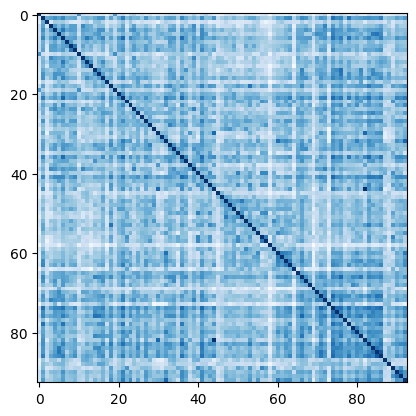

In [112]:
# Draw a heatmap with the summary_similarity_matrix
plt.figure()
# Color scheme blues
plt.imshow(summary_similarity_matrix, cmap = 'Blues')

In [113]:
# Run the community detection algorithm

def get_topics(title_similarity, num_topics = 8, bonus_constant = 0.25, min_size = 3):

  proximity_bonus_arr = np.zeros_like(title_similarity)
  for row in range(proximity_bonus_arr.shape[0]):
    for col in range(proximity_bonus_arr.shape[1]):
      if row == col:
        proximity_bonus_arr[row, col] = 0
      else:
        proximity_bonus_arr[row, col] = 1/(abs(row-col)) * bonus_constant

  title_similarity += proximity_bonus_arr

  title_nx_graph = nx.from_numpy_array(title_similarity)

  desired_num_topics = num_topics
  # Store the accepted partitionings
  topics_title_accepted = []

  resolution = 0.85
  resolution_step = 0.01
  iterations = 40

  # Find the resolution that gives the desired number of topics
  topics_title = []
  while len(topics_title) not in [desired_num_topics, desired_num_topics + 1, desired_num_topics + 2]:
    topics_title = community.louvain_communities(title_nx_graph, weight = 'weight', resolution = resolution)
    resolution += resolution_step
  topic_sizes = [len(c) for c in topics_title]
  sizes_sd = np.std(topic_sizes)
  modularity = community.modularity(title_nx_graph, topics_title, weight = 'weight', resolution = resolution)

  lowest_sd_iteration = 0
  # Set lowest sd to inf
  lowest_sd = float('inf')

  for i in range(iterations):
    topics_title = community.louvain_communities(title_nx_graph, weight = 'weight', resolution = resolution)
    modularity = community.modularity(title_nx_graph, topics_title, weight = 'weight', resolution = resolution)

    # Check SD
    topic_sizes = [len(c) for c in topics_title]
    sizes_sd = np.std(topic_sizes)

    topics_title_accepted.append(topics_title)

    if sizes_sd < lowest_sd and min(topic_sizes) >= min_size:
      lowest_sd_iteration = i
      lowest_sd = sizes_sd

  # Set the chosen partitioning to be the one with highest modularity
  topics_title = topics_title_accepted[lowest_sd_iteration]
  print(f'Best SD: {lowest_sd}, Best iteration: {lowest_sd_iteration}')

  topic_id_means = [sum(e)/len(e) for e in topics_title]
  # Arrange title_topics in order of topic_id_means
  topics_title = [list(c) for _, c in sorted(zip(topic_id_means, topics_title), key = lambda pair: pair[0])]
  # Create an array denoting which topic each chunk belongs to
  chunk_topics = [None] * title_similarity.shape[0]
  for i, c in enumerate(topics_title):
    for j in c:
      chunk_topics[j] = i

  return {
    'chunk_topics': chunk_topics,
    'topics': topics_title
    }

In [114]:
# Set num_topics to be 1/4 of the number of chunks, or 8, whichever is smaller
num_topics = min(int(num_1_chunks / 4), 8)
topics_out = get_topics(summary_similarity_matrix, num_topics = num_topics, bonus_constant = 0.2)
chunk_topics = topics_out['chunk_topics']
topics = topics_out['topics']

Best SD: 2.4995867427031855, Best iteration: 35


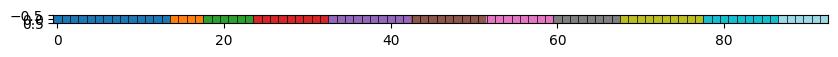

In [115]:
# Plot a heatmap of this array
plt.figure(figsize = (10, 4))
plt.imshow(np.array(chunk_topics).reshape(1, -1), cmap = 'tab20')
# Draw vertical black lines for every 1 of the x-axis
for i in range(1, len(chunk_topics)):
  plt.axvline(x = i - 0.5, color = 'black', linewidth = 0.5)

**Stage 3: Summaries**

Once we have the clusters of similar titles and summaries, we use LLMChain on these clusters to generate wihtin cluster summarized title and within cluster summaries using summarize_stage_2() function. And also a final summary based on the summaries of the clusters.

In [116]:
def summarize_stage_2(stage_1_outputs, topics, summary_num_words = 250):
  print(f'Stage 2 start time {datetime.now()}')

  # Prompt that passes in all the titles of a topic, and asks for an overall title of the topic
  title_prompt_template = """Write an informative title that summarizes each of the following groups of titles. Make sure that the titles capture as much information as possible,
  and are different from each other:
  {text}

  Return your answer in a numbered list, with new line separating each title:
  1. Title 1
  2. Title 2
  3. Title 3

  TITLES:
  """

  map_prompt_template = """Wite a 75-100 word summary of the following text describing emotions of these patients and medical delivery gaps:
    {text}

    CONCISE SUMMARY:"""

  combine_prompt_template = 'Write a ' + str(summary_num_words) + """-word summary of the following, describing emotions of these patients and medical delivery gaps. Finish your answer:
  {text}
  """ + str(summary_num_words) + """-WORD SUMMARY:"""

  title_prompt = PromptTemplate(template=title_prompt_template, input_variables=["text"])
  map_prompt = PromptTemplate(template=map_prompt_template, input_variables=["text"])
  combine_prompt = PromptTemplate(template=combine_prompt_template, input_variables=["text"])

  topics_data = []
  for c in topics:
    topic_data = {
      'summaries': [stage_1_outputs[chunk_id]['summary'] for chunk_id in c],
      'titles': [stage_1_outputs[chunk_id]['title'] for chunk_id in c]
    }
    topic_data['summaries_concat'] = ' '.join(topic_data['summaries'])
    topic_data['titles_concat'] = ', '.join(topic_data['titles'])
    topics_data.append(topic_data)

  # Get a list of each community's summaries (concatenated)
  topics_summary_concat = [c['summaries_concat'] for c in topics_data]
  topics_titles_concat = [c['titles_concat'] for c in topics_data]

  # Concat into one long string to do the topic title creation
  topics_titles_concat_all = ''''''
  for i, c in enumerate(topics_titles_concat):
    topics_titles_concat_all += f'''{i+1}. {c}
    '''

  # print('topics_titles_concat_all', topics_titles_concat_all)

  title_llm = OpenAI(temperature=0, model_name = 'gpt-3.5-turbo-instruct')
  title_llm_chain = LLMChain(llm = title_llm, prompt = title_prompt)
  title_llm_chain_input = [{'text': topics_titles_concat_all}]
  title_llm_chain_results = title_llm_chain.apply(title_llm_chain_input)


  # Split by new line
  titles = title_llm_chain_results[0]['text'].split('\n')
  # Remove any empty titles
  titles = [t for t in titles if t != '']
  # Remove spaces at start or end of each title
  titles = [t.strip() for t in titles]

  map_llm = OpenAI(temperature=0, model_name = 'gpt-3.5-turbo-instruct')
  reduce_llm = OpenAI(temperature=0, model_name = 'gpt-3.5-turbo-instruct', max_tokens = -1)

  # Run the map-reduce chain
  docs = [Document(page_content=t) for t in topics_summary_concat]
  chain = load_summarize_chain(chain_type="map_reduce", map_prompt = map_prompt, combine_prompt = combine_prompt, return_intermediate_steps = True,
                              llm = map_llm, reduce_llm = reduce_llm)

  output = chain({"input_documents": docs}, return_only_outputs = True)
  summaries = output['intermediate_steps']
  stage_2_outputs = [{'title': t, 'summary': s} for t, s in zip(titles, summaries)]
  final_summary = output['output_text']

  # Return: stage_1_outputs (title and summary), stage_2_outputs (title and summary), final_summary, chunk_allocations
  out = {
    'stage_2_outputs': stage_2_outputs,
    'final_summary': final_summary
  }
  print(f'Stage 2 done time {datetime.now()}')

  return out

In [117]:
# Query GPT-3 to get a summarized title for each topic_data
out = summarize_stage_2(stage_1_outputs, topics, summary_num_words = 250)
stage_2_outputs = out['stage_2_outputs']
stage_2_titles = [e['title'] for e in stage_2_outputs]
stage_2_summaries = [e['summary'] for e in stage_2_outputs]
final_summary = out['final_summary']

Stage 2 start time 2024-04-29 06:55:54.193656
Stage 2 done time 2024-04-29 06:56:01.742628


In [118]:
stage_2_outputs

[{'title': '1. Understanding the Emotional Impact of Medical Delivery Gaps on Patients with AAOCA',
  'summary': ' This text discusses the emotional impact of medical delivery gaps on patients and their families, particularly those dealing with congenital heart defects. It highlights the need for improved support and understanding for patients, as well as the importance of timely and thorough medical care. The text also touches on the frustration and uncertainty that patients and their loved ones may experience when faced with medical delivery gaps, and the potential impact on young athletes and their families.'},
 {'title': '2. The Emotional Toll of Caring for Sick Loved Ones and the Need for Better Medical Support',
  'summary': " The text discusses the emotional toll and gaps in medical delivery faced by patients with chronic illnesses. A parent shares their concerns about their child's health and the lack of support from medical professionals at school. This highlights the struggle

In [119]:
final_summary

'\n\nThis text discusses the emotional impact of medical delivery gaps on patients and their families, particularly those dealing with chronic conditions and rare medical conditions. It highlights the struggles and frustrations faced by patients and their loved ones as they navigate the healthcare system, including difficulties finding appropriate care and lack of communication between medical professionals. The emotional toll on patients and their families is emphasized, with feelings of uncertainty, frustration, and disappointment being common experiences. The text also emphasizes the need for improved support and understanding for patients, as well as timely and thorough medical care. It also highlights the importance of addressing emotional needs and improving communication in the medical field to ensure a positive patient experience. The experiences of patients and their families navigating the healthcare system are shared, shedding light on the need for better education and suppo

In [69]:
for i in range(len(stage_2_outputs)):
  print (stage_2_outputs[i]['title'])

1. Understanding the Emotional Impact of Medical Delivery Gaps in Patients with AAOCA
2. Navigating Emotions and Medical Delivery Gaps in Cardiology
3. Emotional Experiences and Medical Delivery Gaps in Patients with Asymptomatic COVID-19
4. Emotional Turmoil and Medical Delivery Gaps in Critical Care Patients
5. The Emotional Toll of Heart Conditions on Young Patients
6. The Emotional Toll of Surviving a Heart Attack
7. Exploring Patient Emotions and Medical Delivery Gaps in Surgical Treatment for Anomalies
8. The Importance of Early Heart Checks for Children
9. The Emotional Toll of Parenting a Child with a Medical Condition
10. Emotional Support and Medical Delivery Gaps for Patients with Rare Diseases



***Final Summary for interview1 transcript (05-03-2021_AAOCA_Deidentified_EG_parents):***

This text delves into the emotional toll that medical delivery gaps can have on patients and their families, particularly those with rare conditions. The use of complex medical terminology and acronyms can create communication gaps, leading to frustration and anxiety for patients. These gaps not only affect the quality of medical care but also cause negative emotions such as fear and uncertainty. The importance of clear communication and support from medical professionals is highlighted, as well as the need for more awareness and understanding of rare conditions. The personal stories of patients and their families illustrate the impact of these gaps and the emotional journey they face in seeking proper medical care.

The text also sheds light on the emotional struggles and lack of resources faced by patients with celiac disease, heart conditions, and other rare diseases. It emphasizes the need for improved medical care and support for these patients, as well as better communication and efficiency in the healthcare system. The emotional impact of medical delivery gaps during the COVID-19 pandemic is also discussed, highlighting the importance of being an advocate for oneself and seeking second opinions.

The emotional toll of having a child with a serious diagnosis is also explored, emphasizing the need for a strong support system and better integration of mental health services in medical care. The text also discusses the emotional struggles of patients and their families as they navigate through medical exams and treatments, highlighting the gaps in medical delivery where patients may not have access to necessary support and resources to cope with their emotions.

Overall, this text highlights the significant emotional impact of medical delivery gaps on patients and their families. It emphasizes the need for improved communication, support, and understanding from medical professionals, as well as more awareness and resources for rare conditions. The personal stories shared by patients and their families serve as a reminder of the importance of addressing these gaps and providing proper medical care for all individuals.


**Final Summary for interview2 transcript (06-21-2021_AAOCA_Deidentified_EG_parents):**



This text delves into the emotional impact and gaps in medical delivery experienced by patients and medical professionals during virtual interviews. It sheds light on the need for improved technology and communication strategies to bridge the gap between virtual and in-person medical interactions. Through interviews with patients affected by anomalous coronary artery, the text highlights the emotional toll and lack of understanding from medical professionals, emphasizing the need for better communication and education within the medical field. It also brings attention to the challenges faced by patients with co-occurring disorders and the need for a more comprehensive approach to healthcare.

The text showcases a range of emotions experienced by patients and their families, such as fear, uncertainty, frustration, and gratitude. It emphasizes the importance of timely and efficient medical care, as well as the need for support and reassurance for patients and their families during and after treatment. The emotional toll of medical delivery gaps on patients and their families is a significant issue that needs to be addressed in order to improve patient outcomes and alleviate the burden on patients and their loved ones.

The text also highlights the impact of medical delivery gaps on young patients and their families, with one child finding relief from constant worry after reassurance from a cardiologist. It discusses the emotional distress and frustration that patients and their families can face when there are gaps in medical delivery, leading to delayed or inadequate care. The lack of communication, understanding, and timely treatment can cause anxiety, fear, and uncertainty for patients and their loved ones. This emphasizes the need for improved medical delivery systems to prevent such emotional tolls and improve patient outcomes.

Overall, the text emphasizes the need for efficient and timely medical delivery to address the emotional toll on patients and their families. It also highlights the importance of improved communication and support from healthcare providers to alleviate the emotional burden on patients and their loved ones. The experiences shared by patients and their families showcase the need for a more patient-centered approach to healthcare, with a focus on addressing emotional needs and improving overall medical delivery.

**Final Summary for interview3 transcript (08-03-2021_Deidentified_EG_AAOCA_Parents_RL):**



This text delves into the emotional experiences of patients and their families when faced with gaps in medical delivery. Through personal stories, the challenges of receiving timely and comprehensive care are highlighted, along with the impact on patients' quality of life. Effective communication and support from healthcare providers are crucial, but often lacking, leading to feelings of frustration, confusion, and fear for patients and their families. The need for improved medical delivery systems to prevent gaps and provide accurate diagnoses is emphasized, as well as the importance of collaboration between medical facilities and researchers. Despite the initial fears and challenges, patients and their families have learned to cope with their conditions, but there is still a need for better medical delivery to bridge the gap between diagnosis and treatment. The emotional toll of medical delivery gaps is particularly evident in cases of high-risk pregnancies, rare conditions, and heart anomalies in young athletes. The text also highlights the importance of emotional support and the need for improved resources and communication in the medical community. Overall, the experiences shared by patients and their families shed light on the need for better medical delivery systems to alleviate the emotional burden and provide timely and efficient care.

**Final Summary for interview4 transcript (10-05-21_Deidentified_Parents):**



This text discusses the emotional impact of medical delivery gaps on patients and their families, particularly those dealing with chronic conditions and rare medical conditions. It highlights the struggles and frustrations faced by patients and their loved ones as they navigate the healthcare system, including difficulties finding appropriate care and lack of communication between medical professionals. The emotional toll on patients and their families is emphasized, with feelings of uncertainty, frustration, and disappointment being common experiences. The text also emphasizes the need for improved support and understanding for patients, as well as timely and thorough medical care. It also highlights the importance of addressing emotional needs and improving communication in the medical field to ensure a positive patient experience. The experiences of patients and their families navigating the healthcare system are shared, shedding light on the need for better education and support for both patients and educators. The text also emphasizes the impact of medical delivery gaps on young athletes and their families, as well as the importance of addressing these gaps to prevent similar situations from happening to others. Overall, the text highlights the need for improvements in the medical delivery system to address the emotional toll on patients and their families and provide personalized and attentive care.